In [1]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

iris = load_iris(as_frame=True)
X_iris = iris.data[['petal length (cm)', 'petal width (cm)']].values
y_iris = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2,random_state=43)
tree_clf.fit(X_iris,y_iris)

DecisionTreeClassifier(max_depth=2, random_state=43)

In [2]:
## Decision Tree

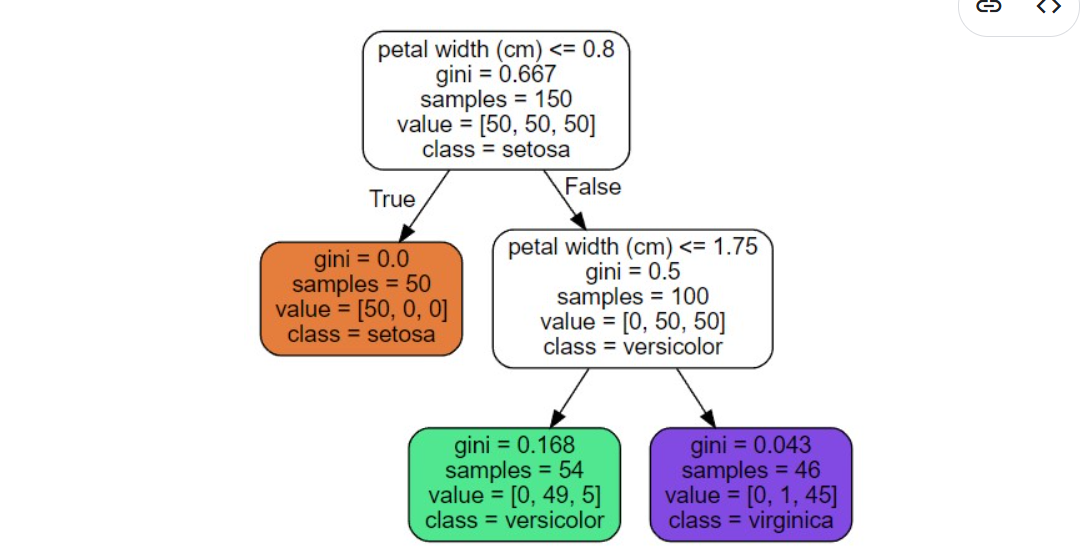

In [3]:
tree_clf.tree_

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


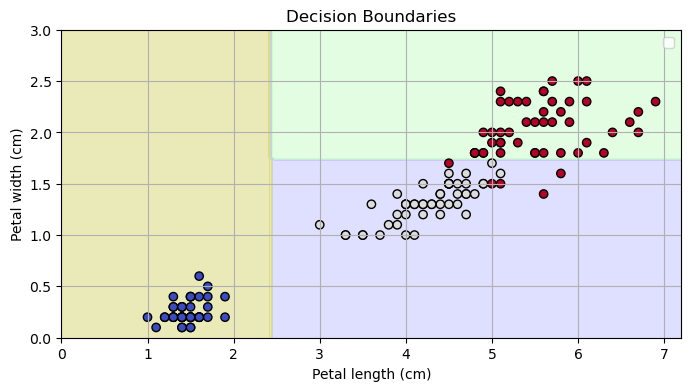

In [4]:
lengths, widths = np.meshgrid(np.linspace(0, 7.2, 100), np.linspace(0, 3, 100))
X_iris_all = np.c_[lengths.ravel(), widths.ravel()]
X_grid = np.c_[lengths.ravel(),widths.ravel()]
y_pred = tree_clf.predict(X_grid).reshape(lengths.shape)
from matplotlib.colors import ListedColormap
custom_cmap = ListedColormap(["#bbbb18d9", '#9898ff', '#a0faa0'])
plt.figure(figsize=(8, 4))
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.contourf(lengths, widths, y_pred, alpha=0.3, cmap=custom_cmap)
plt.scatter(X_iris[:, 0], X_iris[:, 1], c=y_iris, edgecolor='k', cmap="coolwarm")
plt.title("Decision Boundaries")
plt.grid()
plt.legend()
plt.show()

In [5]:
X_setosa = X_iris[y_iris == 0]
X_versicolor = X_iris[y_iris == 1]
X_virginica =X_iris[ y_iris == 2]


C:\Users\jitik\AppData\Local\Temp\ipykernel_38620\3237807279.py:12: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_setosa[:,0],X_setosa[:,1],label = 'Setosa',edgecolors='k',cmap = custom_cmap,marker = '^')
C:\Users\jitik\AppData\Local\Temp\ipykernel_38620\3237807279.py:13: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_versicolor[:,0],X_versicolor[:,1],label = 'Versicolor',edgecolors='k',cmap = custom_cmap,marker = 'o')
C:\Users\jitik\AppData\Local\Temp\ipykernel_38620\3237807279.py:14: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_virginica[:,0],X_virginica[:,1],label = 'Virginica',edgecolors='k',cmap = custom_cmap,marker = '*')


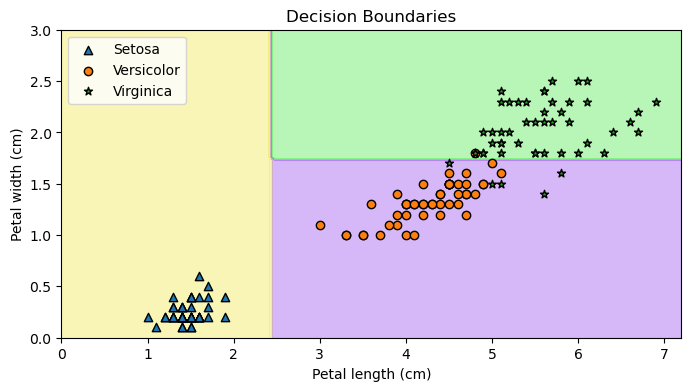

In [6]:
lengths, widths = np.meshgrid(np.linspace(0, 7.2, 100), np.linspace(0, 3, 100))
X_iris_all = np.c_[lengths.ravel(), widths.ravel()]
X_grid = np.c_[lengths.ravel(),widths.ravel()]
y_pred = tree_clf.predict(X_grid).reshape(lengths.shape)
from matplotlib.colors import ListedColormap
custom_cmap = ListedColormap(["#e9e112d9", "#7911ea", "#12e412"])
plt.figure(figsize=(8, 4))
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.contourf(lengths, widths, y_pred, alpha=0.3, cmap=custom_cmap)
# plt.scatter(X_iris[:, 0], X_iris[:, 1], c=y_iris, edgecolor='k', cmap="coolwarm")
plt.scatter(X_setosa[:,0],X_setosa[:,1],label = 'Setosa',edgecolors='k',cmap = custom_cmap,marker = '^')
plt.scatter(X_versicolor[:,0],X_versicolor[:,1],label = 'Versicolor',edgecolors='k',cmap = custom_cmap,marker = 'o')
plt.scatter(X_virginica[:,0],X_virginica[:,1],label = 'Virginica',edgecolors='k',cmap = custom_cmap,marker = '*')
plt.title("Decision Boundaries")
plt.legend()
plt.show()

In [7]:
df = pd.DataFrame({
    'housing':[1,2,3,4,6],
    'names':['h','a','h','f','r']
})
df

,housing,names
0,1,h
1,2,a
2,3,h
3,4,f
4,6,r


In [8]:
col_df = df.columns
tr_df = np.array(df)
pd.DataFrame(tr_df,columns=col_df)

,housing,names
0,1,h
1,2,a
2,3,h
3,4,f
4,6,r


In [9]:
df['housing']

0    1
1    2
2    3
3    4
4    6
Name: housing, dtype: int64

In [10]:
from sklearn.preprocessing import FunctionTransformer

log_trn = FunctionTransformer(np.log,inverse_func=np.exp)
trasnformed = log_trn.fit_transform(df['housing'])
log_trn.inverse_transform(trasnformed)

0    1.0
1    2.0
2    3.0
3    4.0
4    6.0
Name: housing, dtype: float64

In [11]:
tree_clf.predict_proba([[5,1.5]]).round(3)

array([[0.   , 0.907, 0.093]])

In [12]:
tree_clf.predict([[5,1.5]])

array([1])

In [13]:
from sklearn.datasets import make_moons

X_moons,Y_moons = make_moons(n_samples=250,noise = 0.2,random_state=42)
tree_clf_1 = DecisionTreeClassifier(random_state=42)
tree_clf_2 = DecisionTreeClassifier(min_samples_leaf=5,random_state=42)
X_train = X_moons[0:150]
Y_train = Y_moons[0:150]

X_test = X_moons[150:250]
Y_test = Y_moons[150:250]
tree_clf_1.fit(X_train,Y_train)
tree_clf_2.fit(X_train,Y_train)

DecisionTreeClassifier(min_samples_leaf=5, random_state=42)

In [14]:
tree_clf_1_pred = tree_clf_1.predict(X_test)
tree_clf_2_pred = tree_clf_2.predict(X_test)

In [15]:
grid = np.meshgrid(np.linspace(X_test[:,0].min(),X_test[:,0].max(),100),np.linspace(X_test[:,1].min(),X_test[:,1].max(),100))
grid = np.array(grid)

In [16]:
grid

array([[[-1.33300477, -1.29553566, -1.25806655, ...,  2.30149877,
          2.33896788,  2.37643699],
        [-1.33300477, -1.29553566, -1.25806655, ...,  2.30149877,
          2.33896788,  2.37643699],
        [-1.33300477, -1.29553566, -1.25806655, ...,  2.30149877,
          2.33896788,  2.37643699],
        ...,
        [-1.33300477, -1.29553566, -1.25806655, ...,  2.30149877,
          2.33896788,  2.37643699],
        [-1.33300477, -1.29553566, -1.25806655, ...,  2.30149877,
          2.33896788,  2.37643699],
        [-1.33300477, -1.29553566, -1.25806655, ...,  2.30149877,
          2.33896788,  2.37643699]],

       [[-0.75127224, -0.75127224, -0.75127224, ..., -0.75127224,
         -0.75127224, -0.75127224],
        [-0.73000684, -0.73000684, -0.73000684, ..., -0.73000684,
         -0.73000684, -0.73000684],
        [-0.70874144, -0.70874144, -0.70874144, ..., -0.70874144,
         -0.70874144, -0.70874144],
        ...,
        [ 1.31147189,  1.31147189,  1.31147189, ...,  

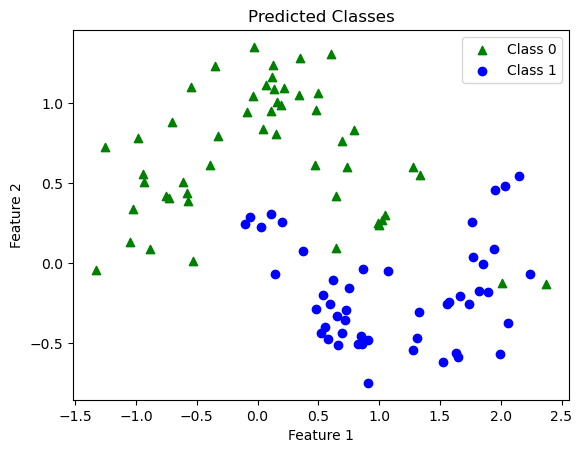

In [17]:
class_0 = tree_clf_1_pred == 0
class_1 = tree_clf_1_pred == 1

plt.scatter(X_test[class_0, 0], X_test[class_0, 1], 
            color='green', marker='^', label='Class 0')

plt.scatter(X_test[class_1, 0], X_test[class_1, 1], 
            color='blue', marker='o', label='Class 1')

plt.legend()
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Predicted Classes")
plt.show()

In [18]:
x1, x2 = grid  # each shape: (100, 100)

In [19]:
X_grid = np.c_[x1.ravel(), x2.ravel()]  # shape (10000, 2)

In [20]:
y_grid_pred_1 = tree_clf_1.predict(X_grid).reshape(x1.shape)
y_grid_pred_2 = tree_clf_2.predict(X_grid).reshape(x1.shape)

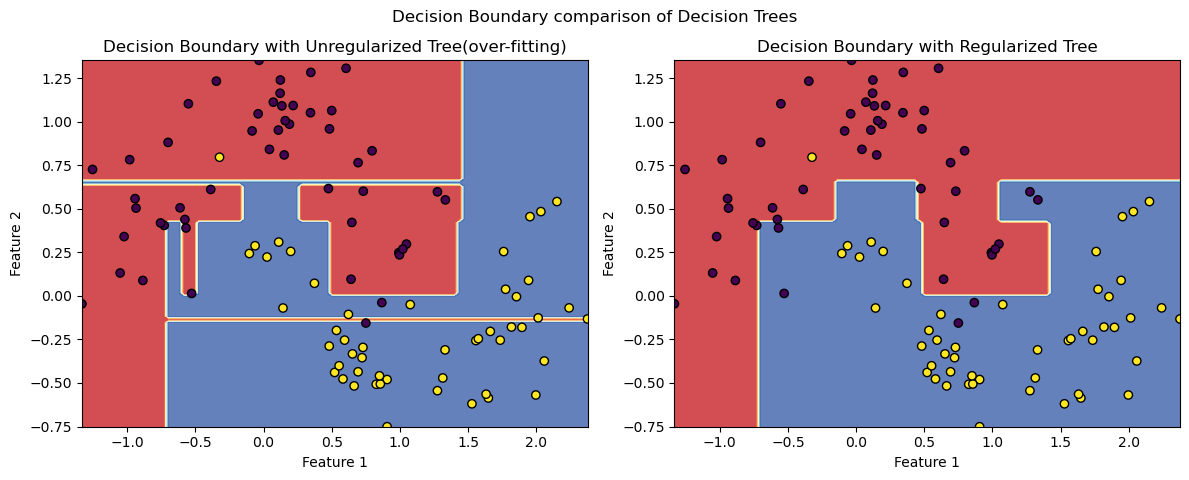

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].contourf(x1, x2, y_grid_pred_1, cmap=plt.cm.RdYlBu, alpha=0.8)
axes[0].scatter(X_test[:, 0], X_test[:, 1], c=Y_test, edgecolor='k')
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")
axes[0].set_title("Decision Boundary with Unregularized Tree(over-fitting)")

axes[1].contourf(x1, x2, y_grid_pred_2, cmap=plt.cm.RdYlBu, alpha=0.8)
axes[1].scatter(X_test[:, 0], X_test[:, 1], c=Y_test, edgecolor='k')
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")
axes[1].set_title("Decision Boundary with Regularized Tree")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle('Decision Boundary comparison of Decision Trees')
plt.show()


In [22]:
tree_clf_1.score(X_test,Y_test)

0.95

In [23]:
tree_clf_2.score(X_test,Y_test)

0.93

In [24]:
X_quad = np.random.rand(200,1) - 0.5

In [25]:
y_quad = 5 * X_quad ** 2 + 0.5 * np.random.rand(200,1)
y_quad

array([[1.22460881],
       [1.34953538],
       [0.14460638],
       [1.03737597],
       [0.2973651 ],
       [1.19937038],
       [1.20202883],
       [1.1386834 ],
       [0.16895356],
       [0.41012407],
       [0.65436942],
       [0.3735673 ],
       [0.47699382],
       [1.58328921],
       [0.80530656],
       [0.94042891],
       [0.08506417],
       [0.47305573],
       [0.30179417],
       [0.24084945],
       [0.51270958],
       [1.50848946],
       [0.8982773 ],
       [1.02683156],
       [0.99998138],
       [0.40920236],
       [1.03774676],
       [0.1961421 ],
       [0.26146408],
       [0.59556854],
       [0.79720237],
       [0.25458276],
       [1.04122525],
       [0.82022705],
       [0.92432371],
       [0.61094025],
       [0.41431365],
       [0.07878567],
       [0.317086  ],
       [0.26147243],
       [0.95660915],
       [0.62796145],
       [1.21316659],
       [1.38084586],
       [0.80753829],
       [0.87189645],
       [0.95055867],
       [0.502

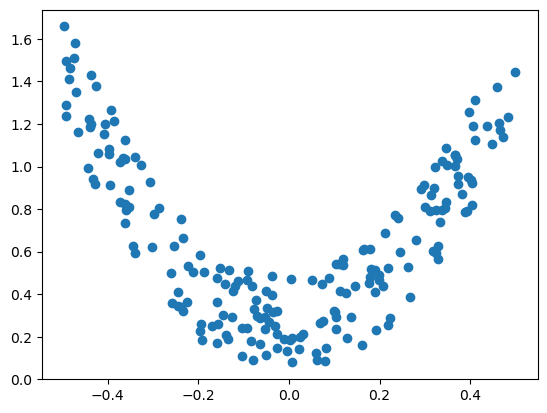

In [26]:
plt.scatter(X_quad,y_quad)

In [27]:
from sklearn.tree import DecisionTreeRegressor
tree_reg = DecisionTreeRegressor(max_depth=2,random_state=42)
tree_reg.fit(X_quad,y_quad)

DecisionTreeRegressor(max_depth=2, random_state=42)

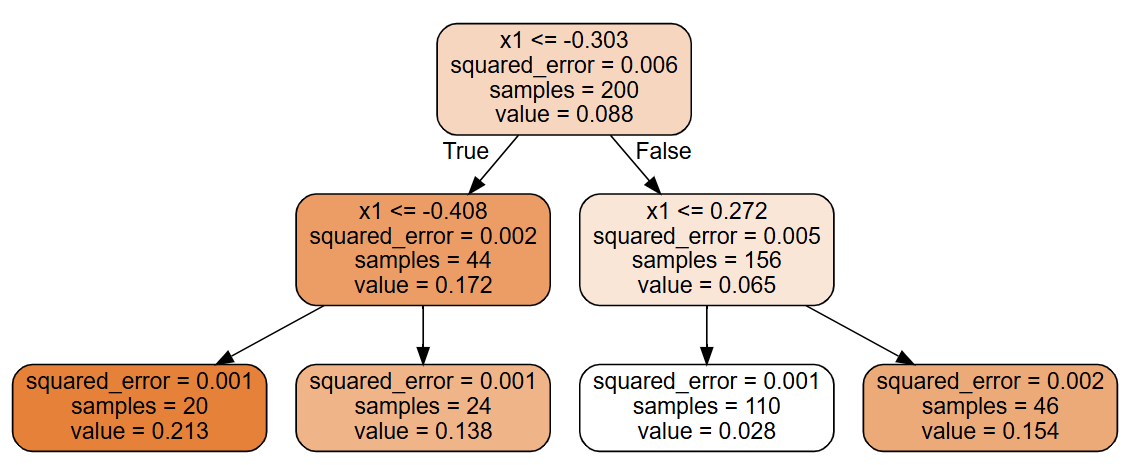

In [28]:
tree_reg.tree_.threshold

array([-0.36146811, -0.46793079, -2.        , -2.        ,  0.28594024,
       -2.        , -2.        ])

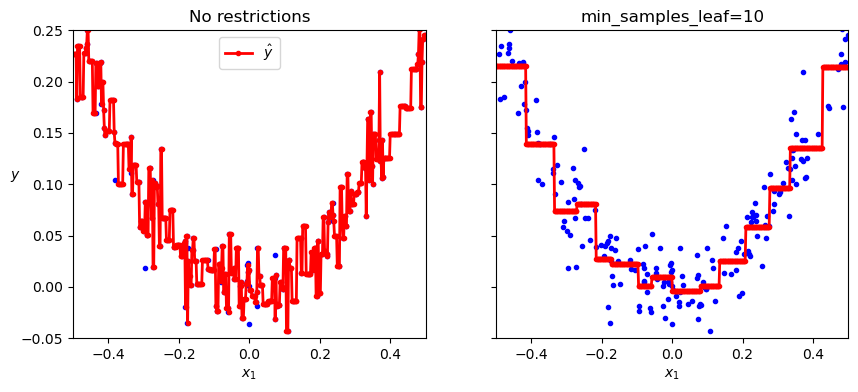

In [29]:
X_quad = np.random.rand(200, 1) - 0.5 
y_quad = X_quad ** 2 + 0.025 * np.random.randn(200, 1)

tree_reg1 = DecisionTreeRegressor(random_state=42)
tree_reg2 = DecisionTreeRegressor(random_state=42, min_samples_leaf=10)
tree_reg1.fit(X_quad, y_quad)
tree_reg2.fit(X_quad, y_quad)

x1 = np.linspace(-0.5, 0.5, 500).reshape(-1, 1)
y_pred1 = tree_reg1.predict(x1)
y_pred2 = tree_reg2.predict(x1)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)

plt.sca(axes[0])
plt.plot(X_quad, y_quad, "b.")
plt.plot(x1, y_pred1, "r.-", linewidth=2, label=r"$\hat{y}$")
plt.axis([-0.5, 0.5, -0.05, 0.25])
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper center")
plt.title("No restrictions")

plt.sca(axes[1])
plt.plot(X_quad, y_quad, "b.")
plt.plot(x1, y_pred2, "r.-", linewidth=2, label=r"$\hat{y}$")
plt.axis([-0.5, 0.5, -0.05, 0.25])
plt.xlabel("$x_1$")
plt.title(f"min_samples_leaf={tree_reg2.min_samples_leaf}")
plt.show()

In [42]:
from sklearn.model_selection import train_test_split,GridSearchCV
X,Y = make_moons(n_samples=10000,noise = 0.4)

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.3,random_state=42,shuffle=True)

In [54]:
decision_tree = DecisionTreeClassifier(random_state=42)

param_grid = [
    {
        'max_depth':[1,2,3,5,7],
        'max_leaf_nodes':[2,3,4,6],
        'criterion':['gini','entropy','log_loss']
    },
]

grid_search = GridSearchCV(decision_tree,param_grid=param_grid,scoring = 'accuracy',cv = 4,n_jobs=-2,verbose=1)
grid_search.fit(X_train,Y_train)

Fitting 4 folds for each of 60 candidates, totalling 240 fits


GridSearchCV(cv=4, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-2,
             param_grid=[{'criterion': ['gini', 'entropy', 'log_loss'],
                          'max_depth': [1, 2, 3, 5, 7],
                          'max_leaf_nodes': [2, 3, 4, 6]}],
             scoring='accuracy', verbose=1)

In [55]:
grid_search.best_params_

{'criterion': 'gini', 'max_depth': 2, 'max_leaf_nodes': 4}

In [56]:
grid_search.best_score_

0.858

In [57]:
best_decision_tree = grid_search.best_estimator_

In [58]:
test_preds = best_decision_tree.predict(X_test)

In [61]:
from sklearn.metrics import classification_report

report = classification_report(Y_test,test_preds)

In [63]:
print(report)

              precision    recall  f1-score   support

           0       0.88      0.82      0.85      1482
           1       0.83      0.89      0.86      1518

    accuracy                           0.85      3000
   macro avg       0.85      0.85      0.85      3000
weighted avg       0.85      0.85      0.85      3000



In [ ]:
from sklearn.model_selection import ShuffleSplit

ShuffleSplit(1000,)